# 07 - SHAP Explainability

**Insurance Claim Fraud Detection & Action Recommendation System**

This notebook explains the frozen, calibrated model from Notebooks 04-06 - it
does not retrain, re-tune, re-threshold, re-select, or modify any frozen
artifact. Every number and prediction used below is either loaded directly
from Drive or re-derived deterministically from the exact same frozen model +
pipeline Notebook 06 already used for the final evaluation - nothing here
feeds back into an earlier decision.

**What this notebook does:**
1. Loads the frozen calibrated model, preprocessing pipeline, and
   threshold/tier config - recreates nothing
2. Extracts the underlying fitted tree model from inside the calibration
   wrapper, since TreeSHAP explains tree structure, not a post-hoc
   probability recalibration
3. Verifies, with asserts (not just print statements), that every SHAP value
   below maps to the correct named feature
4. Step 1 - computes SHAP values across the test set for global feature
   importance (bar + beeswarm), cross-checked against Notebook 01's EDA
   signal ranking
5. Step 2 - identifies flagged test claims at the frozen 0.15 threshold and
   samples ~30 of them for local explanation
6. Step 3 - computes per-claim local SHAP drivers and exports a single,
   self-contained JSON handoff file for Notebook 08 (local Qwen) - plus a
   few waterfall figures for the report

**Explicitly out of scope here:** retraining, hyperparameter search, model
re-selection, re-calibration, re-thresholding, redefining risk tiers, or
running any LLM (Qwen is Notebook 08, not this notebook).

**A note on why `test.parquet` is opened again:** Notebook 06 called itself
"the only place in the project that opens `test.parquet`" - true at the time,
and still true in spirit: Notebook 06 was the first and *decision-relevant*
read (the locked, one-shot performance evaluation). This notebook reads the
same file again, read-only, purely to *explain* an already-final, already-
frozen model and its already-final predictions. Nothing computed here
influences model choice, threshold, or tiers - all three were locked before
this notebook exists.

## 1. Environment & Google Drive Setup

Same conventions as Notebooks 01-06: everything derives from one
`PROJECT_ROOT`, Drive is mounted first, and every expected input is verified
to exist before this notebook does any work.

In [1]:
"""Notebook 07 - SHAP Explainability: imports and shared configuration."""
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

TARGET_COL = "FraudFound_P"
RANDOM_STATE = 42

# Same fixed categorical palette as Notebooks 01/03/04/05/06, kept self-contained here.
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}

saved_files = []  # every artifact written to Drive is recorded here for the final recap
print(f"Libraries imported. shap version: {shap.__version__}")

Libraries imported. shap version: 0.52.0


### Mount Google Drive

In [2]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ModuleNotFoundError as exc:
    raise RuntimeError(
        "This notebook is designed to run in Google Colab with the team's shared "
        "Drive mounted. `google.colab` is not available in this environment - open "
        "the notebook in Colab and re-run."
    ) from exc

Mounted at /content/drive


### Define project paths

In [3]:
PROJECT_ROOT = Path("/content/drive/MyDrive/InsuranceFraudProject")

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_EDA_DIR = RESULTS_DIR / "figures" / "eda"
FIGURES_SHAP_DIR = RESULTS_DIR / "figures" / "shap"
MODELS_DIR = PROJECT_ROOT / "models"

TEST_PATH = DATA_PROCESSED_DIR / "test.parquet"
PIPELINE_PATH = MODELS_DIR / "preprocessing_pipeline.joblib"
CALIBRATED_MODEL_PATH = MODELS_DIR / "calibrated_model.joblib"
RISK_CONFIG_PATH = MODELS_DIR / "risk_config.json"
BEST_MODEL_CONFIG_PATH = MODELS_DIR / "best_model_config.json"
METRICS_JSON_PATH = RESULTS_DIR / "metrics.json"
SIGNAL_RANKING_PATH = FIGURES_EDA_DIR / "feature_fraud_signal_ranking.csv"

SHAP_EXPORT_PATH = RESULTS_DIR / "shap_claim_briefs.json"  # Notebook 08's handoff file

FIGURES_SHAP_DIR.mkdir(parents=True, exist_ok=True)

print("Project configuration")
print("-" * 60)
print(f"PROJECT_ROOT              : {PROJECT_ROOT}")
print(f"TEST_PATH                  : {TEST_PATH}")
print(f"PIPELINE_PATH              : {PIPELINE_PATH}")
print(f"CALIBRATED_MODEL_PATH      : {CALIBRATED_MODEL_PATH}")
print(f"RISK_CONFIG_PATH           : {RISK_CONFIG_PATH}")
print(f"BEST_MODEL_CONFIG_PATH     : {BEST_MODEL_CONFIG_PATH}")
print(f"METRICS_JSON_PATH          : {METRICS_JSON_PATH}")
print(f"SIGNAL_RANKING_PATH        : {SIGNAL_RANKING_PATH}")
print(f"SHAP_EXPORT_PATH           : {SHAP_EXPORT_PATH}")

Project configuration
------------------------------------------------------------
PROJECT_ROOT              : /content/drive/MyDrive/InsuranceFraudProject
TEST_PATH                  : /content/drive/MyDrive/InsuranceFraudProject/data/processed/test.parquet
PIPELINE_PATH              : /content/drive/MyDrive/InsuranceFraudProject/models/preprocessing_pipeline.joblib
CALIBRATED_MODEL_PATH      : /content/drive/MyDrive/InsuranceFraudProject/models/calibrated_model.joblib
RISK_CONFIG_PATH           : /content/drive/MyDrive/InsuranceFraudProject/models/risk_config.json
BEST_MODEL_CONFIG_PATH     : /content/drive/MyDrive/InsuranceFraudProject/models/best_model_config.json
METRICS_JSON_PATH          : /content/drive/MyDrive/InsuranceFraudProject/results/metrics.json
SIGNAL_RANKING_PATH        : /content/drive/MyDrive/InsuranceFraudProject/results/figures/eda/feature_fraud_signal_ranking.csv
SHAP_EXPORT_PATH           : /content/drive/MyDrive/InsuranceFraudProject/results/shap_claim_briefs.js

### Verify expected inputs exist

Five inputs are required. `metrics.json` (Notebook 06) and
`feature_fraud_signal_ranking.csv` (Notebook 01) are optional cross-checks -
used if present, skipped with a clear warning otherwise - since this
notebook's core job, explaining the frozen model, does not strictly depend on
either.

In [4]:
missing_inputs = []
for label, path in [
    ("test.parquet", TEST_PATH), ("preprocessing_pipeline.joblib", PIPELINE_PATH),
    ("calibrated_model.joblib", CALIBRATED_MODEL_PATH), ("risk_config.json", RISK_CONFIG_PATH),
    ("best_model_config.json", BEST_MODEL_CONFIG_PATH),
]:
    if not path.exists():
        missing_inputs.append((label, path))

if missing_inputs:
    details = "\n".join(f"  - {label}: {path}" for label, path in missing_inputs)
    raise FileNotFoundError(
        f"Missing required input(s):\n{details}\n\n"
        "Run Notebooks 02 through 06 first - this notebook loads their saved outputs "
        "rather than recreating them."
    )

for label, path in [("metrics.json", METRICS_JSON_PATH), ("feature_fraud_signal_ranking.csv", SIGNAL_RANKING_PATH)]:
    if not path.exists():
        print(f"WARNING: optional cross-check input missing - {label} not found at {path}. "
              "The corresponding cross-check below will be skipped, not faked.")

print("Found all required inputs.")

Found all required inputs.


## 2. Load the Frozen Artifacts

Loaded, not recreated - identical philosophy to Notebook 06. `risk_config.json`
carries the operating threshold and tier boundaries chosen on validation in
Notebook 05; they are used **verbatim** below.

In [5]:
with open(RISK_CONFIG_PATH, "r", encoding="utf-8") as f:
    risk_config = json.load(f)

with open(BEST_MODEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    best_model_config = json.load(f)

preprocessing_pipeline = joblib.load(PIPELINE_PATH)

operating_threshold = risk_config["operating_threshold"]
LOW_RISK_MAX = risk_config["risk_tiers"]["low_max"]
HIGH_RISK_MIN = risk_config["risk_tiers"]["high_min"]

print(f"Calibration method:  {risk_config['calibration_method']}")
print(f"Operating threshold: {operating_threshold}  (loaded from risk_config.json - not recomputed)")
print(f"Risk tiers:           Low < {LOW_RISK_MAX}  |  Medium < {HIGH_RISK_MIN}  |  High >= {HIGH_RISK_MIN}")
print(f"Source model:         {best_model_config['model_name']} + {best_model_config['balancing_strategy']} "
      f"(Optuna trial #{best_model_config['optuna']['trial_number']})")

Calibration method:  isotonic
Operating threshold: 0.15  (loaded from risk_config.json - not recomputed)
Risk tiers:           Low < 0.075  |  Medium < 0.15  |  High >= 0.15
Source model:         XGBoost + class_weight (Optuna trial #58)


### Reconstruct the class needed to unpickle the calibrated model

Same reasoning as Notebook 06: `calibrated_model.joblib` was pickled from a
kernel where `EarlyStoppingGBDT` was defined; unpickling a custom class
requires it to be defined, under the same name, wherever `joblib.load` runs.
Reproduced here **unchanged from Notebooks 04-06**, purely so the saved model
can be loaded - nothing here re-fits it. `CalibratedClassifierCV` and (if the
SMOTENC arm had won) `SMOTENC`/`ImbPipeline` are standard scikit-learn /
imbalanced-learn classes, so unlike `EarlyStoppingGBDT` they don't need to be
redefined - just importable, which the imports above already ensure.

In [6]:
class EarlyStoppingGBDT(ClassifierMixin, BaseEstimator):
    """Wraps an XGBoost/LightGBM classifier so a plain .fit(X, y) call automatically
    carves out an internal validation slice and applies early stopping.

    Reproduced unchanged from Notebooks 04-06, purely to unpickle
    calibrated_model.joblib - not used to fit anything new in this notebook.
    """

    def __init__(self, base_estimator, early_stopping_rounds: int = 50,
                 val_fraction: float = 0.15, random_state: int = RANDOM_STATE):
        self.base_estimator = base_estimator
        self.early_stopping_rounds = early_stopping_rounds
        self.val_fraction = val_fraction
        self.random_state = random_state

    def fit(self, X, y):
        X_fit, X_inner_val, y_fit, y_inner_val = train_test_split(
            X, y, test_size=self.val_fraction, stratify=y, random_state=self.random_state,
        )
        self.estimator_ = clone(self.base_estimator)
        if isinstance(self.estimator_, XGBClassifier):
            self.estimator_.set_params(early_stopping_rounds=self.early_stopping_rounds)
            self.estimator_.fit(X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)], verbose=False)
        elif isinstance(self.estimator_, LGBMClassifier):
            self.estimator_.fit(
                X_fit, y_fit, eval_set=[(X_inner_val, y_inner_val)],
                callbacks=[lgb.early_stopping(stopping_rounds=self.early_stopping_rounds, verbose=False)],
            )
        else:
            raise TypeError(f"EarlyStoppingGBDT doesn't know how to early-stop {type(self.estimator_).__name__}")
        self.classes_ = self.estimator_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        check_is_fitted(self, "estimator_")
        return self.estimator_.predict_proba(X)


calibrated_model = joblib.load(CALIBRATED_MODEL_PATH)
print(f"Loaded calibrated model: {type(calibrated_model).__name__}")

Loaded calibrated model: CalibratedClassifierCV


## 3. Extract the Base Tree Model for SHAP

### Why SHAP must run on the tree model, not the calibration wrapper

`calibrated_model` (per Notebook 05) is a `CalibratedClassifierCV` - or, if
`calibration_method` had been `"none"`, the frozen model directly - wrapping
the tree model Notebook 04 actually selected and trained. Calibration is a
**post-hoc, monotonic transform** fit on top of the tree model's raw score:
it reshapes probabilities to be better-calibrated, but it does not change
*which claims rank higher than which*, and it has no tree structure of its
own for TreeSHAP to walk.

TreeSHAP needs the actual fitted tree ensemble, so the code below unwraps, in
order: the calibration layer (`CalibratedClassifierCV` / `FrozenEstimator`),
any `imblearn` pipeline wrapper (only present if the SMOTENC arm had won in
Notebook 04), and the `EarlyStoppingGBDT` wrapper - to reach the fitted
`XGBClassifier`/`LGBMClassifier` underneath. **SHAP values below explain that
tree model's raw output (its ranking of claims), not the calibrated
probability directly** - but because calibration is monotonic (a higher raw
score always means a higher calibrated probability), a feature that pushes
the raw score up always pushes the calibrated probability up too. The SHAP
drivers below are therefore still the correct explanation for *why a claim
scored high*, even though the number scored is technically pre-calibration.

In [7]:
def extract_base_tree_model(model):
    """Unwrap calibration -> (optional) imblearn Pipeline -> EarlyStoppingGBDT to
    reach the actual fitted tree ensemble TreeSHAP needs. Fails loudly - returns
    only a fitted XGBClassifier/LGBMClassifier, never anything else."""
    target = model

    if isinstance(target, CalibratedClassifierCV):
        check_is_fitted(target, "calibrated_classifiers_")
        calibrated_classifier = target.calibrated_classifiers_[0]
        inner = None
        for attr in ("estimator", "base_estimator"):
            if hasattr(calibrated_classifier, attr):
                inner = getattr(calibrated_classifier, attr)
                break
        if inner is None:
            raise AttributeError(
                "Could not find the prefit estimator inside CalibratedClassifierCV - "
                "checked 'estimator' and 'base_estimator', found neither. sklearn's "
                "internal naming for this may have changed again."
            )
        target = inner

    if type(target).__name__ == "FrozenEstimator":
        target = target.estimator

    if hasattr(target, "steps"):  # imblearn Pipeline - only present if SMOTENC arm won
        target = target.steps[-1][1]

    if isinstance(target, EarlyStoppingGBDT):
        check_is_fitted(target, "estimator_")
        target = target.estimator_

    if not isinstance(target, (XGBClassifier, LGBMClassifier)):
        raise TypeError(
            f"Expected to land on a fitted XGBClassifier or LGBMClassifier after "
            f"unwrapping calibrated_model, but got {type(target).__name__} instead. "
            "The calibration/pipeline structure may not match what Notebooks 04-05 "
            "produced - do not proceed to SHAP with the wrong object."
        )
    return target


MODEL_CLASS_TO_NAME = {"XGBClassifier": "XGBoost", "LGBMClassifier": "LightGBM"}

base_tree_model = extract_base_tree_model(calibrated_model)
extracted_model_name = MODEL_CLASS_TO_NAME[type(base_tree_model).__name__]
assert extracted_model_name == best_model_config["model_name"], (
    f"Extracted base tree model is {extracted_model_name}, but best_model_config.json "
    f"says the selected model was {best_model_config['model_name']} - extraction "
    "logic landed on the wrong object."
)
print(f"Extracted base tree model: {type(base_tree_model).__name__} ({extracted_model_name}) "
      "- confirmed to match best_model_config.json.")
print("This is the object shap.TreeExplainer runs on below - never `calibrated_model` itself.")

Extracted base tree model: XGBClassifier (XGBoost) - confirmed to match best_model_config.json.
This is the object shap.TreeExplainer runs on below - never `calibrated_model` itself.


In [8]:
def snapshot_fitted_state(model) -> np.ndarray:
    """Grab one representative fitted attribute, to detect an accidental mutation
    later - same pattern as Notebook 04's mutation guard."""
    if hasattr(model, "coef_"):
        return np.asarray(model.coef_).copy()
    if hasattr(model, "feature_importances_"):
        return np.asarray(model.feature_importances_).copy()
    raise AttributeError(f"Don't know how to snapshot fitted state for {type(model).__name__}")


base_tree_model_snapshot_before = snapshot_fitted_state(base_tree_model)
print("Snapshotted the base tree model's fitted state - checked again after SHAP runs below.")

Snapshotted the base tree model's fitted state - checked again after SHAP runs below.


## 4. Prepare Test Data & Verify Feature-Name Alignment

`test.parquet` is opened here read-only, exactly as Notebook 06 opened it -
transformed with `.transform()` only (the pipeline is never refit) - and used
only to explain the already-frozen model (see the title cell's note on why
opening it again here is not a leakage or re-decision concern).

**Why this section matters:** SHAP values are just numbers in an array - they
mean nothing without knowing which column each one belongs to. If the
feature names used for plots and exports don't line up, in order, with the
columns `preprocessing_pipeline.transform()` actually produced, every
explanation below would be silently mislabeled (a value that's really
"Fault" could get reported as "BasePolicy"). Every check below is designed
to catch that *before* any SHAP value is computed, not after.

In [9]:
test_df = pd.read_parquet(TEST_PATH)
X_test_df = test_df.drop(columns=[TARGET_COL])

# .astype(np.float64): the pipeline's "passthrough" block mixes plain numeric columns
# with the boolean Age_was_missing flag - pandas silently resolves that mix to
# dtype=object when passed through as one block. sklearn/XGBoost's own predict methods
# coerce this internally without complaint, but SHAP's TreeExplainer builds an
# xgboost.DMatrix directly and rejects object-dtype columns outright. The cast below
# is a pure dtype fix (every value here is already numeric) - not a value change.
X_test = preprocessing_pipeline.transform(X_test_df).astype(np.float64)
y_test = test_df[TARGET_COL].to_numpy()

y_proba_test = calibrated_model.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test >= operating_threshold).astype(int)
test_risk_tier = np.where(y_proba_test >= HIGH_RISK_MIN, "High",
                    np.where(y_proba_test >= LOW_RISK_MAX, "Medium", "Low"))

print(f"test_df: {test_df.shape[0]:,} rows  |  fraud rate: {y_test.mean() * 100:.2f}%")
print(f"X_test: {X_test.shape}")
print(f"Flagged at {operating_threshold}: {int(y_pred_test.sum()):,} claims "
      f"({100 * y_pred_test.mean():.1f}% of test set)")

if METRICS_JSON_PATH.exists():
    with open(METRICS_JSON_PATH, "r", encoding="utf-8") as f:
        logged_metrics = json.load(f)
    fresh_pr_auc = average_precision_score(y_test, y_proba_test)
    fresh_recall = recall_score(y_test, y_pred_test, zero_division=0)
    fresh_precision = precision_score(y_test, y_pred_test, zero_division=0)
    logged = logged_metrics["test"]["metrics"]
    for name, fresh_value in [("pr_auc", fresh_pr_auc), ("recall", fresh_recall), ("precision", fresh_precision)]:
        diff = abs(fresh_value - logged[name])
        assert diff < 1e-9, (
            f"Freshly-recomputed test {name} ({fresh_value:.6f}) does not match Notebook "
            f"06's logged metrics.json value ({logged[name]:.6f}) - the frozen model, "
            "pipeline, or threshold may have changed since Notebook 06 ran."
        )
    print("PASSED: freshly-recomputed PR-AUC/recall/precision match Notebook 06's logged "
          "metrics.json exactly - this notebook is explaining the exact same frozen "
          "predictions, not a drifted recomputation.")
else:
    print("SKIPPED: metrics.json not found - cross-check against Notebook 06's logged "
          "test metrics was skipped (see the optional-input warning in Section 1).")

test_df: 2,313 rows  |  fraud rate: 5.97%
X_test: (2313, 93)
Flagged at 0.15: 176 claims (7.6% of test set)
PASSED: freshly-recomputed PR-AUC/recall/precision match Notebook 06's logged metrics.json exactly - this notebook is explaining the exact same frozen predictions, not a drifted recomputation.


### Reconstruct which encoded columns belong to which original feature

In [10]:
def build_feature_groups(pipeline: ColumnTransformer) -> list:
    """Reconstruct, purely from the fitted pipeline's own transformers_ (never
    redefines Notebook 02's column lists), which contiguous block of post-encoding
    columns belongs to which original source column. This is the single source of
    truth used below for the alignment check, the human-readable export, and every
    aggregated ('grouped') SHAP view."""
    groups = []
    offset = 0
    for name, transformer, columns in pipeline.transformers_:
        if name == "remainder":
            continue
        if name == "nominal":
            fitted = pipeline.named_transformers_[name]
            for col, categories in zip(columns, fitted.categories_):
                n_out = len(categories)
                groups.append({"source_column": col, "kind": name,
                                "encoded_indices": list(range(offset, offset + n_out))})
                offset += n_out
        else:
            for col in columns:
                groups.append({"source_column": col, "kind": name, "encoded_indices": [offset]})
                offset += 1
    return groups


feature_names_out = list(preprocessing_pipeline.get_feature_names_out())
feature_groups = build_feature_groups(preprocessing_pipeline)

# --- Alignment check 1: the groups exactly cover every output column, in order ---
all_grouped_indices = [i for g in feature_groups for i in g["encoded_indices"]]
assert all_grouped_indices == list(range(len(feature_names_out))), (
    "The reconstructed feature groups do not exactly cover, in order, every output "
    "column of the fitted pipeline - the source-column mapping used for every SHAP "
    "explanation below would be wrong."
)

# --- Alignment check 2: counts agree between the pipeline, X_test, and the model ---
assert len(feature_names_out) == X_test.shape[1] == base_tree_model.n_features_in_, (
    f"Feature count mismatch: pipeline names={len(feature_names_out)}, "
    f"X_test columns={X_test.shape[1]}, model expects={base_tree_model.n_features_in_}. "
    "SHAP would be computed against the wrong number of features."
)

# --- Alignment check 3: every group's claimed indices actually carry that source
#     column's name in sklearn's own get_feature_names_out() output - an independent
#     cross-check against the manual traversal above, not just trusting it blindly ---
for g in feature_groups:
    if g["kind"] == "nominal":
        expected_prefix = f"nominal__{g['source_column']}_"
        for idx in g["encoded_indices"]:
            assert feature_names_out[idx].startswith(expected_prefix), (
                f"Column {idx} ('{feature_names_out[idx]}') was assigned to nominal "
                f"source column '{g['source_column']}' but its name does not start "
                f"with '{expected_prefix}' - the nominal block boundaries are misaligned."
            )
    else:
        expected_name = f"{g['kind']}__{g['source_column']}"
        idx = g["encoded_indices"][0]
        assert feature_names_out[idx] == expected_name, (
            f"Column {idx} was assigned to source column '{g['source_column']}' "
            f"(kind={g['kind']}) but get_feature_names_out() calls it "
            f"'{feature_names_out[idx]}', not '{expected_name}' - block boundaries "
            "are misaligned."
        )

print(f"PASSED: {len(feature_groups)} original features map onto {len(feature_names_out)} "
      "post-encoding columns, in order, with every block boundary independently "
      "cross-checked against get_feature_names_out().")

PASSED: 29 original features map onto 93 post-encoding columns, in order, with every block boundary independently cross-checked against get_feature_names_out().


### A concrete spot-check, not just an internal-consistency check

Flip one real test row's `Sex` to the other category, transform both
versions, and confirm that *only* the encoded columns the mapping above
claims belong to `Sex` actually change - and nothing else does. This is the
same class of bug ("we hit this warning before") a naming mismatch would
cause, made concrete on real data rather than trusted in the abstract.

In [11]:
sex_group = next(g for g in feature_groups if g["source_column"] == "Sex")
probe_row = X_test_df.iloc[[0]].copy()
original_sex = probe_row["Sex"].iloc[0]
flipped_sex = "Female" if original_sex == "Male" else "Male"
probe_row_flipped = probe_row.copy()
probe_row_flipped["Sex"] = flipped_sex

encoded_original = preprocessing_pipeline.transform(probe_row)[0]
encoded_flipped = preprocessing_pipeline.transform(probe_row_flipped)[0]
changed_indices = set(np.flatnonzero(encoded_original != encoded_flipped).tolist())

assert changed_indices == set(sex_group["encoded_indices"]), (
    f"Flipping Sex from '{original_sex}' to '{flipped_sex}' changed encoded columns "
    f"{sorted(changed_indices)}, but the feature-group mapping claims Sex only owns "
    f"columns {sex_group['encoded_indices']} - the name-to-column mapping is wrong."
)
print(f"PASSED: flipping Sex ('{original_sex}' -> '{flipped_sex}') on a real test row "
      f"changed exactly the {len(changed_indices)} encoded column(s) the feature-group "
      "mapping claims belong to Sex, and nothing else.")

PASSED: flipping Sex ('Male' -> 'Female') on a real test row changed exactly the 2 encoded column(s) the feature-group mapping claims belong to Sex, and nothing else.


## 5. Step 1 - Global Feature Importance

### Computing SHAP values

`shap.TreeExplainer` on a tree ensemble, using the default
`feature_perturbation="tree_path_dependent"`, is an *exact*, fast algorithm -
it needs no background dataset and no sampling. For a dataset this size
(a few thousand test rows, well under a hundred post-encoding features),
this runs in well under a minute, so SHAP values below are computed across
**the entire test set, not a subsample** - stated explicitly per this
notebook's own runtime-disclosure requirement, even though subsampling
turned out not to be necessary here.

SHAP values below are in the base tree model's **raw margin (log-odds)
output space**, not calibrated-probability points - see Section 3's note on
why that is still the correct explanation for calibrated-probability
rankings.

In [12]:
explainer = shap.TreeExplainer(base_tree_model)
X_test_named = pd.DataFrame(X_test, columns=feature_names_out, index=test_df.index)

raw_explanation = explainer(X_test_named)

# XGBoost binary classification gives one SHAP output per sample; some LightGBM/SHAP
# version combinations instead return a (n_samples, n_features, 2) array (one slice per
# class) - normalize to "SHAP values for the positive/fraud class" either way.
if raw_explanation.values.ndim == 3:
    positive_class_index = 1
    shap_values_matrix = raw_explanation.values[:, :, positive_class_index]
    base_values = raw_explanation.base_values[:, positive_class_index]
else:
    shap_values_matrix = raw_explanation.values
    base_values = np.asarray(raw_explanation.base_values)
    if base_values.ndim == 0:
        base_values = np.full(shap_values_matrix.shape[0], float(base_values))

assert shap_values_matrix.shape == X_test.shape, (
    f"SHAP values shape {shap_values_matrix.shape} does not match X_test shape "
    f"{X_test.shape} - something went wrong extracting the positive-class slice."
)

base_tree_model_snapshot_after = snapshot_fitted_state(base_tree_model)
assert np.array_equal(base_tree_model_snapshot_before, base_tree_model_snapshot_after), (
    "The base tree model's fitted state changed after computing SHAP values - it "
    "must never be refit or mutated by this notebook."
)

print(f"Computed SHAP values for {shap_values_matrix.shape[0]:,} test claims across "
      f"{shap_values_matrix.shape[1]} post-encoding features - full test set, no sampling.")
print(f"Mean base value (expected raw score with no feature information): {np.mean(base_values):.4f}")

Computed SHAP values for 2,313 test claims across 93 post-encoding features - full test set, no sampling.
Mean base value (expected raw score with no feature information): 0.0181


### Group one-hot columns back to original features

Summing SHAP values within a one-hot group is exact, not an approximation -
SHAP's additive property (`base_value + sum(shap values) = raw score`) is
preserved by summation, so grouping loses no information while making every
downstream view (bar chart, EDA cross-check, per-claim drivers, waterfalls)
speak in original feature names instead of one-hot dummy columns.

In [13]:
def build_grouped_shap(shap_matrix: np.ndarray, feature_groups: list, source_df: pd.DataFrame):
    """Collapse one-hot-expanded SHAP columns back to one column per ORIGINAL
    feature (summing within each group), paired with that feature's actual
    human-readable value from source_df. Used for the report-facing bar chart, the
    EDA cross-check, and every per-claim explanation below."""
    n_rows = shap_matrix.shape[0]
    grouped_shap = np.zeros((n_rows, len(feature_groups)))
    grouped_display = np.empty((n_rows, len(feature_groups)), dtype=object)
    names = []
    for j, g in enumerate(feature_groups):
        grouped_shap[:, j] = shap_matrix[:, g["encoded_indices"]].sum(axis=1)
        grouped_display[:, j] = source_df[g["source_column"]].to_numpy()
        names.append(g["source_column"])
    return grouped_shap, grouped_display, names


grouped_shap_matrix, grouped_display_matrix, grouped_feature_names = build_grouped_shap(
    shap_values_matrix, feature_groups, X_test_df,
)

# Additivity must survive grouping: summing one-hot columns together cannot change
# each row's total, since SHAP values within a row already sum to (raw score - base value).
assert np.allclose(grouped_shap_matrix.sum(axis=1), shap_values_matrix.sum(axis=1), atol=1e-6), (
    "Grouped SHAP values no longer sum to the same per-row total as the ungrouped "
    "values - build_grouped_shap() is not a pure aggregation."
)
print(f"Grouped {len(feature_names_out)} post-encoding columns back into "
      f"{len(grouped_feature_names)} original features.")

Grouped 93 post-encoding columns back into 29 original features.


### Global importance: bar chart (original features) and beeswarm (post-encoding detail)

The bar chart below aggregates one-hot dummies back to each original
feature - the right view for the report and for the EDA cross-check next.
The beeswarm needs a numeric per-feature value to color by, which a grouped,
mixed-type (categorical + numeric) feature doesn't naturally have, so it is
shown in the post-encoding feature space instead - useful technical detail
(e.g. which specific category of a feature matters), not the headline
ranking.

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/global_importance_bar.png  (grouped back to original features)


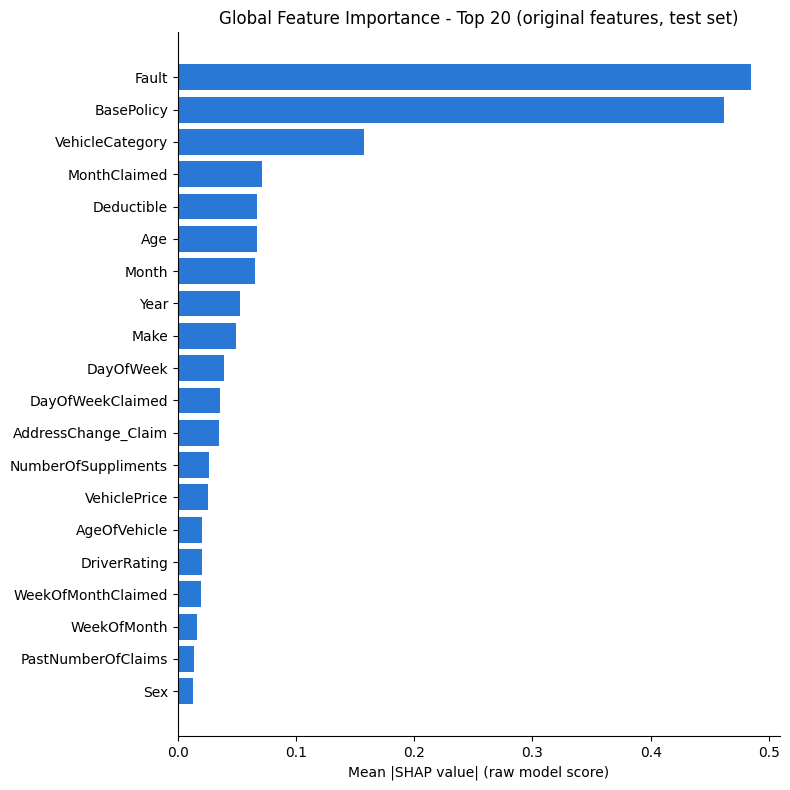

,feature,mean_abs_shap
0,Fault,0.485106
1,BasePolicy,0.461850
2,VehicleCategory,0.157664
3,MonthClaimed,0.071276
4,Deductible,0.067459
5,Age,0.066902
6,Month,0.065123
7,Year,0.052633
8,Make,0.049600
9,DayOfWeek,0.039077


In [14]:
def save_figure(fig, filename: str, note: str = "") -> Path:
    """Save a figure to the SHAP figures directory, record it, and print the path."""
    out_path = FIGURES_SHAP_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    saved_files.append(out_path)
    print(f"Saved figure -> {out_path}" + (f"  ({note})" if note else ""))
    return out_path


mean_abs_grouped = np.abs(grouped_shap_matrix).mean(axis=0)
global_importance_df = pd.DataFrame({
    "feature": grouped_feature_names, "mean_abs_shap": mean_abs_grouped,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

TOP_N_BAR = 20
top_bar_df = global_importance_df.head(TOP_N_BAR).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(top_bar_df["feature"], top_bar_df["mean_abs_shap"], color=PALETTE["blue"])
ax.set_xlabel("Mean |SHAP value| (raw model score)")
ax.set_title(f"Global Feature Importance - Top {TOP_N_BAR} (original features, test set)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
save_figure(fig, "global_importance_bar.png", note="grouped back to original features")
plt.show()

display(global_importance_df.head(15))

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/global_beeswarm.png  (post-encoding feature space, for the numeric color axis - see the grouped bar chart above for the per-original-feature ranking)


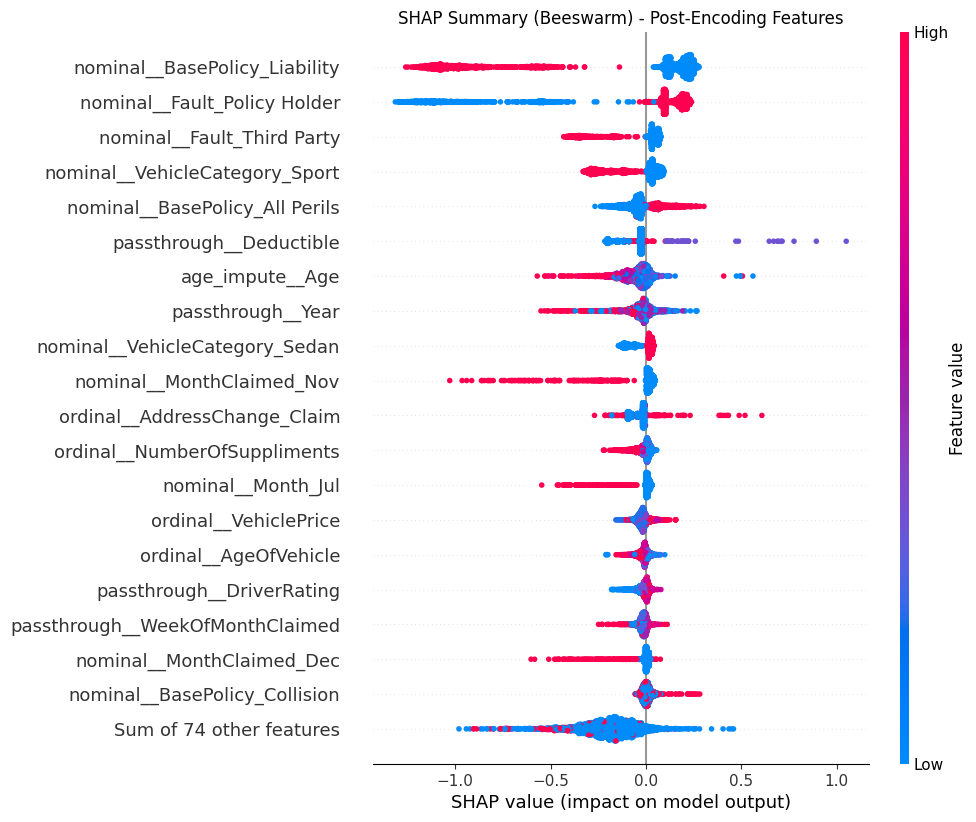

In [15]:
encoded_explanation = shap.Explanation(
    values=shap_values_matrix, base_values=base_values, data=X_test,
    feature_names=feature_names_out,
)

shap.plots.beeswarm(encoded_explanation, max_display=20, show=False)
fig = plt.gcf()
fig.axes[0].set_title("SHAP Summary (Beeswarm) - Post-Encoding Features")
save_figure(fig, "global_beeswarm.png",
            note="post-encoding feature space, for the numeric color axis - see the "
                 "grouped bar chart above for the per-original-feature ranking")
plt.show()

### Cross-checking SHAP's global ranking against Notebook 01's EDA

Notebook 01's `feature_fraud_signal_ranking.csv` ranks features by a
univariate effect size (Cramer's V for categorical, rank-biserial for
numeric) - a single feature at a time, with no notion of interactions.
Comparing its top features against SHAP's top (grouped) features says
something a univariate test structurally cannot: whether a feature the model
leans on hard is one EDA already flagged, or one that only matters once the
model can combine it with others.

In [16]:
TOP_N_CROSS_CHECK = 15
agreements, shap_only, eda_only = [], [], []

if SIGNAL_RANKING_PATH.exists():
    signal_summary = pd.read_csv(SIGNAL_RANKING_PATH)
    required_cols = {"feature", "effect_size"}
    assert required_cols.issubset(signal_summary.columns), (
        f"feature_fraud_signal_ranking.csv is missing expected column(s) "
        f"{required_cols - set(signal_summary.columns)} - Notebook 01's output format "
        "may have changed."
    )
    eda_ranked = signal_summary.sort_values("effect_size", ascending=False).reset_index(drop=True)
    eda_top = set(eda_ranked.head(TOP_N_CROSS_CHECK)["feature"])
    shap_top = set(global_importance_df.head(TOP_N_CROSS_CHECK)["feature"])

    # Only compare over features both rankings actually cover - Notebook 01 tested a
    # curated subset (Section 7.5), not necessarily every column that survived into the model.
    common_features = set(eda_ranked["feature"]) & set(global_importance_df["feature"])

    agreements = sorted(eda_top & shap_top)
    shap_only = sorted(f for f in shap_top if f in common_features and f not in eda_top)
    eda_only = sorted(f for f in eda_top if f not in shap_top)

    comparison_df = global_importance_df.head(TOP_N_CROSS_CHECK).merge(
        eda_ranked[["feature", "effect_size", "p_value"]], on="feature", how="left",
    )
    display(comparison_df)

    cross_check_md = f"""
**Agree in both top {TOP_N_CROSS_CHECK}:** {', '.join(agreements) if agreements else '(none)'}.

**High in SHAP, weak/absent in Notebook 01's univariate ranking:**
{', '.join(shap_only) if shap_only else '(none)'} - candidates for interaction effects
the tree model exploits that a one-feature-at-a-time test can't see (a feature can
matter a lot in *combination* with others while looking weak alone).

**High in EDA, lower in SHAP's top {TOP_N_CROSS_CHECK}:**
{', '.join(eda_only) if eda_only else '(none)'} - a univariately strong feature the
model may be capturing redundantly through a correlated feature ranked above it instead.
"""
    display(Markdown(cross_check_md))
    cross_check_summary_str = f"{len(agreements)} of the top {TOP_N_CROSS_CHECK} features agreed with Notebook 01's EDA ranking"
else:
    print("SKIPPED: feature_fraud_signal_ranking.csv not found - EDA cross-check skipped "
          "(see the optional-input warning in Section 1).")
    cross_check_summary_str = "EDA ranking file not found, so no cross-check was possible"

print(cross_check_summary_str)

,feature,mean_abs_shap,effect_size,p_value
0,Fault,0.485106,0.131146,1.428036e-59
1,BasePolicy,0.461850,0.161237,3.325192e-88
2,VehicleCategory,0.157664,0.136892,6.648398e-64
3,MonthClaimed,0.071276,0.044305,3.003256e-05
4,Deductible,0.067459,0.032867,3.789297e-07
5,Age,0.066902,0.054209,6.505809e-03
6,Month,0.065123,0.034914,1.705480e-03
7,Year,0.052633,NaN,NaN
8,Make,0.049600,0.052072,2.195889e-06
9,DayOfWeek,0.039077,0.016406,1.184501e-01



**Agree in both top 15:** AddressChange_Claim, Age, BasePolicy, Deductible, Fault, Make, Month, MonthClaimed, NumberOfSuppliments, VehicleCategory, VehiclePrice.

**High in SHAP, weak/absent in Notebook 01's univariate ranking:**
AgeOfVehicle, DayOfWeek, DayOfWeekClaimed - candidates for interaction effects
the tree model exploits that a one-feature-at-a-time test can't see (a feature can
matter a lot in *combination* with others while looking weak alone).

**High in EDA, lower in SHAP's top 15:**
AccidentArea, AgeOfPolicyHolder, PastNumberOfClaims, PolicyType - a univariately strong feature the
model may be capturing redundantly through a correlated feature ranked above it instead.


11 of the top 15 features agreed with Notebook 01's EDA ranking


## 6. Step 2 - Select the Sample of Flagged Claims for Local Explanation

Flagged = `y_proba_test >= {operating_threshold}` - exactly Notebook 06's
frozen operating point, not recomputed or re-swept.

**A structural note on "spread across tiers":** in this project's frozen
`risk_config.json`, `risk_tiers.high_min` is *defined as* `operating_threshold`
itself (Notebook 05, Section 6) - so "flagged at the operating threshold" and
"risk_tier == High" are, by construction, exactly the same set of claims.
There is no "flagged Medium" claim to sample. To still give the ~30-claim
sample real variety, it is spread instead across:
- **true-positive vs. false-positive** claims, so briefs get tested against
  both a caught-fraud case and a wrongly-flagged legitimate one, and
- **calibrated-confidence bands** within the flagged set (borderline, just
  above the threshold; moderate; and very-high confidence) - a practical
  stand-in for a tier spread, since every flagged claim here is tier High.

**Sampling logic**, stated explicitly: draw up to 15 true positives and up
to 15 false positives (30 total, or fewer if the flagged set doesn't have
that many of one type - the shortfall is backfilled from the other group so
the total sample size stays at min(30, total flagged)), each drawn
round-robin across confidence bands so no single band dominates either
group, using `random_state=42` for reproducibility.

The cells immediately below add a **separate** sample of genuine Medium- and Low-tier test claims on top of this flagged sample - not a replacement for it - so `shap_claim_briefs.json` ends up with real examples from all three risk tiers, not only High.


In [17]:
N_SAMPLE_CLAIMS = 30
N_TP_TARGET = 15
CONFIDENCE_BAND_EDGES = [operating_threshold, 0.30, 0.60, 1.0 + 1e-9]

flagged_idx = np.where(y_pred_test == 1)[0]
assert len(flagged_idx) > 0, (
    "No test claims were flagged at the frozen threshold - there is nothing for Step 2/3 "
    "(local explanation sampling and the Notebook 08 export) to sample from. This would "
    "mean the frozen model/threshold combination is producing zero positive predictions "
    "on the test set, which contradicts Notebook 06's evaluation - investigate before "
    "proceeding rather than silently producing an empty export."
)
tp_idx = flagged_idx[y_test[flagged_idx] == 1]
fp_idx = flagged_idx[y_test[flagged_idx] == 0]

print(f"Flagged claims: {len(flagged_idx):,}  |  true positives: {len(tp_idx):,}  |  "
      f"false positives: {len(fp_idx):,}")


def sample_with_confidence_spread(idx_pool: np.ndarray, proba: np.ndarray, n_target: int,
                                    band_edges: list, rng: np.random.Generator) -> np.ndarray:
    """Sample up to n_target indices from idx_pool, round-robin across the
    calibrated-probability confidence bands in band_edges, so the sample isn't all
    near-threshold or all extreme-confidence claims. Returns everything if the pool
    is already smaller than n_target."""
    if len(idx_pool) <= n_target:
        return np.sort(idx_pool)
    bands = pd.cut(proba[idx_pool], bins=band_edges, right=False, include_lowest=True)
    band_pools = [rng.permutation(g["idx"].to_numpy()) for _, g in
                  pd.DataFrame({"idx": idx_pool, "band": bands}).groupby("band", observed=True)
                  if len(g) > 0]
    picked = []
    i = 0
    while len(picked) < n_target and any(len(p) > 0 for p in band_pools):
        pool = band_pools[i % len(band_pools)]
        if len(pool) > 0:
            picked.append(pool[-1])
            band_pools[i % len(band_pools)] = pool[:-1]
        i += 1
    return np.sort(np.array(picked))


rng = np.random.default_rng(RANDOM_STATE)
n_tp_target = min(N_TP_TARGET, len(tp_idx))
n_fp_target = min(N_SAMPLE_CLAIMS - n_tp_target, len(fp_idx))
shortfall = N_SAMPLE_CLAIMS - n_tp_target - n_fp_target
if shortfall > 0:
    n_tp_target = min(n_tp_target + shortfall, len(tp_idx))

sampled_tp = sample_with_confidence_spread(tp_idx, y_proba_test, n_tp_target, CONFIDENCE_BAND_EDGES, rng)
sampled_fp = sample_with_confidence_spread(fp_idx, y_proba_test, n_fp_target, CONFIDENCE_BAND_EDGES, rng)
sample_idx = np.sort(np.concatenate([sampled_tp, sampled_fp])).astype(int)

assert set(sample_idx.tolist()).issubset(set(flagged_idx.tolist())), "Sampled a claim that isn't flagged."
assert len(sample_idx) == len(set(sample_idx.tolist())), "Duplicate claim sampled."
print(f"Sampled {len(sample_idx)} flagged claims for local explanation: "
      f"{len(sampled_tp)} true positive, {len(sampled_fp)} false positive.")

sample_band_counts = pd.cut(y_proba_test[sample_idx], bins=CONFIDENCE_BAND_EDGES,
                             right=False, include_lowest=True).value_counts().sort_index()
display(sample_band_counts.to_frame("n_claims_sampled"))

Flagged claims: 176  |  true positives: 40  |  false positives: 136
Sampled 30 flagged claims for local explanation: 15 true positive, 15 false positive.


,n_claims_sampled
"[0.15, 0.3)",20
"[0.3, 0.6)",8
"[0.6, 1.0)",2


### Widening the sample: genuine Medium- and Low-tier claims

The sample above is deliberately limited to flagged (High-tier) claims - by
construction, `risk_tier == High` and `y_pred_test == 1` are the same set in
this project (see the note above). That leaves Notebook 08 with no example
brief for a Medium- or Low-tier claim.

This section widens the sample - it does not touch or resample the flagged
High-tier sample above - by drawing genuine rows from the frozen
`test_risk_tier` array (Section 4), itself built from the frozen calibrated
probabilities `y_proba_test` and the frozen `risk_config.json` tier
boundaries, never recomputed: up to 8 Medium-tier claims and up to 8 Low-tier
claims, sampled uniformly at random. Sampling continues the same
`random_state=42` generator (`rng`) used for the High-tier sample above, so
the whole notebook's sampling stays a single reproducible pass. Every claim
sampled here is a real `test_df` row - nothing is synthesized.


In [18]:
N_MEDIUM_TARGET = 8
N_LOW_TARGET = 8

medium_idx = np.where(test_risk_tier == "Medium")[0]
low_idx = np.where(test_risk_tier == "Low")[0]


def sample_uniform(idx_pool: np.ndarray, n_target: int, rng: np.random.Generator) -> np.ndarray:
    """Sample up to n_target indices uniformly at random (no replacement) from
    idx_pool. Returns everything if the pool is already smaller than n_target."""
    if len(idx_pool) <= n_target:
        return np.sort(idx_pool)
    return np.sort(rng.choice(idx_pool, size=n_target, replace=False))


sampled_medium = sample_uniform(medium_idx, N_MEDIUM_TARGET, rng)
sampled_low = sample_uniform(low_idx, N_LOW_TARGET, rng)

assert set(sampled_medium.tolist()).issubset(set(medium_idx.tolist())), (
    "Sampled a claim outside the Medium tier."
)
assert set(sampled_low.tolist()).issubset(set(low_idx.tolist())), (
    "Sampled a claim outside the Low tier."
)
assert set(sampled_medium.tolist()).isdisjoint(set(sample_idx.tolist())), (
    "Medium sample overlaps the flagged High-tier sample."
)
assert set(sampled_low.tolist()).isdisjoint(set(sample_idx.tolist())), (
    "Low sample overlaps the flagged High-tier sample."
)

print(f"Medium-tier pool: {len(medium_idx):,} claims  |  sampled: {len(sampled_medium)}")
print(f"Low-tier pool:    {len(low_idx):,} claims  |  sampled: {len(sampled_low)}")


Medium-tier pool: 564 claims  |  sampled: 8
Low-tier pool:    1,573 claims  |  sampled: 8


## 7. Step 3 - Per-Claim Local Explanations & the Notebook 08 Handoff Export

For each sampled claim: the grouped local SHAP drivers (already computed in
Step 1 - `grouped_shap_matrix`/`grouped_display_matrix` cover the full test
set, so no new SHAP computation happens here, only slicing and formatting),
its original human-readable feature values (read directly from `test_df` -
each SHAP row corresponds 1:1, same row order and index, to a `test_df` row,
so this is a direct lookup, not a lossy inverse-transform of one-hot/ordinal
codes), and the frozen probability/tier/label.

Direction is reported as the strings `"up"` (pushes the score toward fraud)
or `"down"` (pushes toward legitimate) rather than unicode arrows, for safer
downstream parsing in Notebook 08.

**Honest hedge, restated here where it matters most:** SHAP attributes each
claim's *model score* to its features - it describes association with the
model's output, not a causal claim about the claim itself, and it explains
this specific model's reasoning, not "the truth" about whether the claim is
actually fraud.

In [19]:
TOP_K_DRIVERS = 8


def direction_label(shap_value: float) -> str:
    return "up" if shap_value > 0 else ("down" if shap_value < 0 else "flat")


def to_jsonable(value):
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return None if np.isnan(value) else float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if pd.isna(value):
        return None
    return value


def build_claim_record(row_pos: int) -> dict:
    """One self-contained record for Notebook 08 - no model, pipeline, or Colab
    access needed to use it."""
    original_index = int(test_df.index[row_pos])
    proba = float(y_proba_test[row_pos])
    true_label = int(y_test[row_pos])
    predicted_label = int(y_pred_test[row_pos])
    outcome = ("true_positive" if predicted_label == 1 and true_label == 1
               else "false_positive" if predicted_label == 1 and true_label == 0
               else "false_negative" if predicted_label == 0 and true_label == 1
               else "true_negative")

    driver_order = np.argsort(-np.abs(grouped_shap_matrix[row_pos]))[:TOP_K_DRIVERS]
    top_drivers = [
        {
            "feature": grouped_feature_names[j],
            "value": to_jsonable(grouped_display_matrix[row_pos, j]),
            "shap_contribution": round(float(grouped_shap_matrix[row_pos, j]), 4),
            "direction": direction_label(grouped_shap_matrix[row_pos, j]),
        }
        for j in driver_order
    ]

    original_feature_values = {
        col: to_jsonable(value) for col, value in X_test_df.iloc[row_pos].items()
    }

    return {
        "claim_id": f"TEST-{original_index:05d}",
        "true_label": true_label,
        "prediction_outcome": outcome,
        "calibrated_fraud_probability": round(proba, 4),
        "risk_tier": str(test_risk_tier[row_pos]),
        "model_raw_score": round(float(shap_values_matrix[row_pos].sum() + base_values[row_pos]), 4),
        "shap_base_value": round(float(base_values[row_pos]), 4),
        "original_feature_values": original_feature_values,
        "top_shap_drivers": top_drivers,
    }


claim_records = [build_claim_record(i) for i in sample_idx]
print(f"Built {len(claim_records)} self-contained claim records.")
display(pd.DataFrame(claim_records)[["claim_id", "true_label", "prediction_outcome",
                                      "calibrated_fraud_probability", "risk_tier"]])

Built 30 self-contained claim records.


,claim_id,true_label,prediction_outcome,calibrated_fraud_probability,risk_tier
0,TEST-12437,0,false_positive,0.1743,High
1,TEST-04027,0,false_positive,0.5333,High
2,TEST-07330,0,false_positive,0.1743,High
3,TEST-13495,0,false_positive,0.1743,High
4,TEST-06854,1,true_positive,0.1743,High
5,TEST-09945,1,true_positive,1.0000,High
6,TEST-01682,1,true_positive,0.2456,High
7,TEST-01945,0,false_positive,0.5333,High
8,TEST-04807,0,false_positive,0.5333,High
9,TEST-00111,0,false_positive,0.5333,High


### Appending the Medium- and Low-tier examples

Same `build_claim_record` function, same grouped SHAP drivers already
computed in Step 1 for the full test set (`grouped_shap_matrix` /
`grouped_display_matrix` cover every test row, High/Medium/Low alike) - only
the row positions being looked up differ. The records below are appended to
`claim_records`; the flagged High-tier sample built above is untouched.


In [20]:
medium_low_idx = np.concatenate([sampled_medium, sampled_low]).astype(int)
medium_low_records = [build_claim_record(i) for i in medium_low_idx]

claim_records = claim_records + medium_low_records
sample_idx = np.concatenate([sample_idx, medium_low_idx]).astype(int)

assert len(claim_records) == len(set(c["claim_id"] for c in claim_records)), (
    "Duplicate claim_id after appending the Medium/Low sample."
)

n_high_sampled = sum(c["risk_tier"] == "High" for c in claim_records)
n_medium_sampled = sum(c["risk_tier"] == "Medium" for c in claim_records)
n_low_sampled = sum(c["risk_tier"] == "Low" for c in claim_records)
print(f"Total claim records: {len(claim_records)}  "
      f"({n_high_sampled} High, {n_medium_sampled} Medium, {n_low_sampled} Low)")
display(pd.DataFrame(claim_records)[["claim_id", "true_label", "prediction_outcome",
                                      "calibrated_fraud_probability", "risk_tier"]])


Total claim records: 46  (30 High, 8 Medium, 8 Low)


,claim_id,true_label,prediction_outcome,calibrated_fraud_probability,risk_tier
0,TEST-12437,0,false_positive,0.1743,High
1,TEST-04027,0,false_positive,0.5333,High
2,TEST-07330,0,false_positive,0.1743,High
3,TEST-13495,0,false_positive,0.1743,High
4,TEST-06854,1,true_positive,0.1743,High
5,TEST-09945,1,true_positive,1.0000,High
6,TEST-01682,1,true_positive,0.2456,High
7,TEST-01945,0,false_positive,0.5333,High
8,TEST-04807,0,false_positive,0.5333,High
9,TEST-00111,0,false_positive,0.5333,High


### Save the Notebook 08 handoff file

In [21]:
shap_export = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "source_notebook": "07_shap_explainability.ipynb",
    "model_source": {
        "model_name": best_model_config["model_name"],
        "balancing_strategy": best_model_config["balancing_strategy"],
        "calibration_method": risk_config["calibration_method"],
    },
    "operating_threshold": operating_threshold,
    "risk_tiers": risk_config["risk_tiers"],
    "sampling": {
        "n_claims": len(claim_records),
        "n_true_positive": int(sum(c["prediction_outcome"] == "true_positive" for c in claim_records)),
        "n_false_positive": int(sum(c["prediction_outcome"] == "false_positive" for c in claim_records)),
        "n_high_tier": int(sum(c["risk_tier"] == "High" for c in claim_records)),
        "n_medium_tier": int(sum(c["risk_tier"] == "Medium" for c in claim_records)),
        "n_low_tier": int(sum(c["risk_tier"] == "Low" for c in claim_records)),
        "confidence_bands": [str(b) for b in CONFIDENCE_BAND_EDGES],
        "logic": (
            "High tier: up to 15 true-positive and 15 false-positive flagged claims "
            f"(frozen {operating_threshold} threshold - risk_tier=High and flagged are "
            "the same set by construction), sampled round-robin across calibrated-"
            "probability confidence bands. Medium and Low tiers: up to 8 claims each, "
            "sampled uniformly at random from the genuine test-set rows the frozen "
            "test_risk_tier assignment (risk_config.json boundaries, unchanged) places "
            "in that tier. All sampling uses random_state=42 for reproducibility; every "
            "claim below is a real test-set row, never a synthesized one."
        ),
    },
    "shap_explanation_notes": (
        "SHAP values were computed with shap.TreeExplainer on the base "
        f"{best_model_config['model_name']} model extracted from inside the "
        "calibration wrapper - they explain the tree model's raw (log-odds/margin) "
        "score, not the calibrated probability directly. Calibration is a monotonic "
        "transform on top of that score, so a feature pushing the raw score up "
        "always pushes the calibrated probability up too - the direction of each "
        "driver below is still correct, even though its magnitude is in raw-score "
        "units, not probability points. SHAP values describe association with this "
        "model's output, not a causal claim about the claim itself, and not a claim "
        "that the model's decision is correct."
    ),
    "claims": claim_records,
}

with open(SHAP_EXPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(shap_export, f, indent=2)
saved_files.append(SHAP_EXPORT_PATH)
print(f"Saved -> {SHAP_EXPORT_PATH}  ({len(claim_records)} claims)")


Saved -> /content/drive/MyDrive/InsuranceFraudProject/results/shap_claim_briefs.json  (46 claims)


### A few waterfall figures for the report

A small, varied spread rather than the first N rows: the lowest- and
highest-probability example from each of true-positive and false-positive
(up to four claims), capped at five.

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-06854.png  (true_positive)


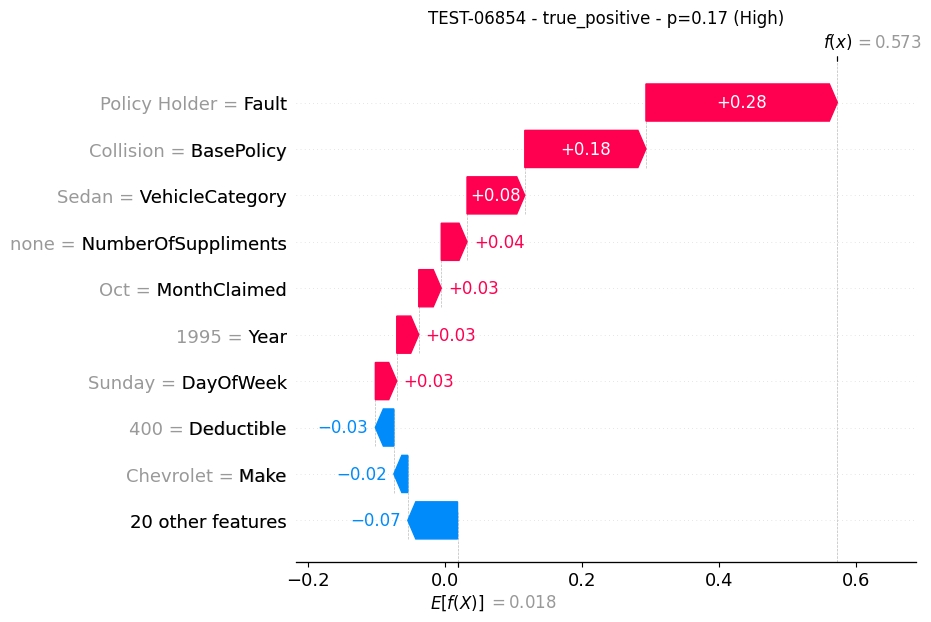

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-02040.png  (true_positive)


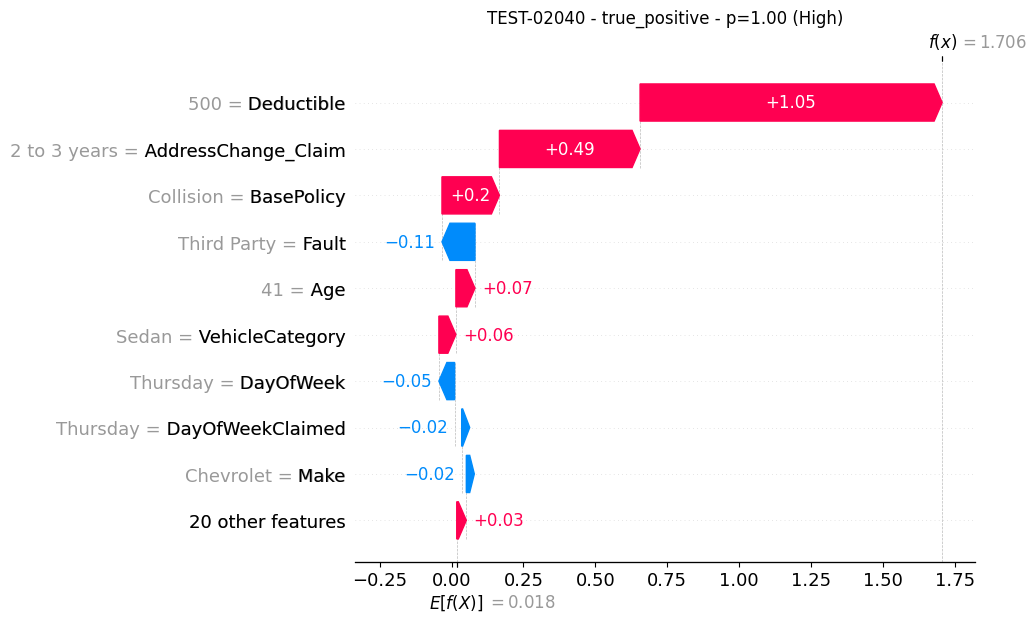

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-12437.png  (false_positive)


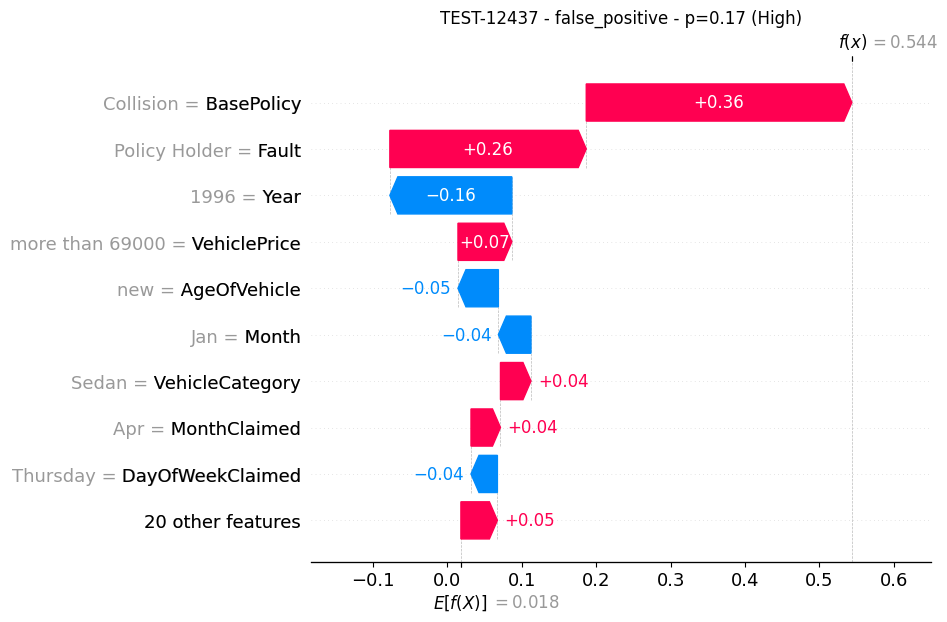

Saved figure -> /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-00835.png  (false_positive)


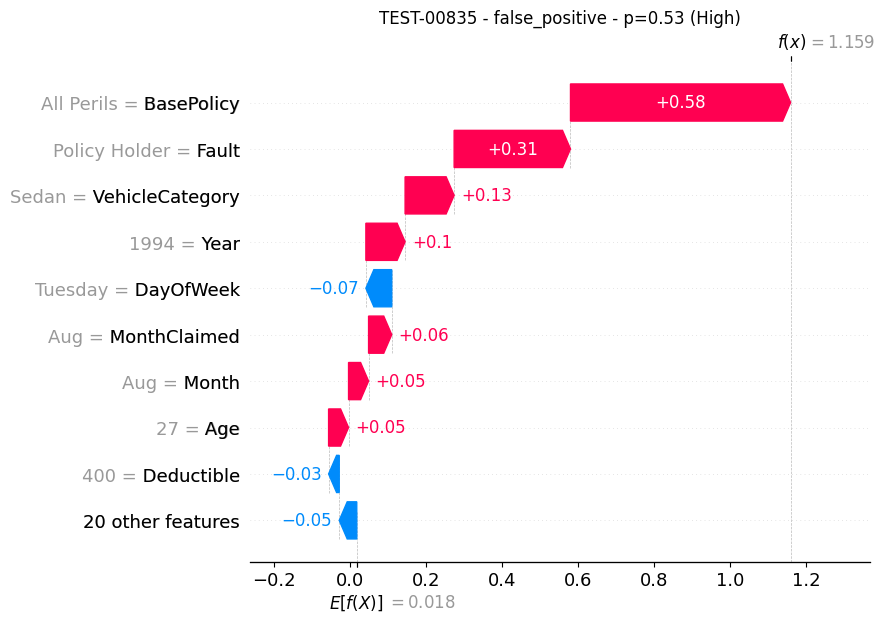

In [22]:
N_WATERFALL_EXAMPLES = 5

tp_records = [c for c in claim_records if c["prediction_outcome"] == "true_positive"]
fp_records = [c for c in claim_records if c["prediction_outcome"] == "false_positive"]

spread_records = []
for group in (tp_records, fp_records):
    group_sorted = sorted(group, key=lambda c: c["calibrated_fraud_probability"])
    if group_sorted:
        spread_records.append(group_sorted[0])
    if len(group_sorted) > 1:
        spread_records.append(group_sorted[-1])

waterfall_records = spread_records[:N_WATERFALL_EXAMPLES] or claim_records[:N_WATERFALL_EXAMPLES]
claim_id_to_row_pos = {rec["claim_id"]: pos for rec, pos in zip(claim_records, sample_idx)}

for rec in waterfall_records:
    row_pos = claim_id_to_row_pos[rec["claim_id"]]
    single_explanation = shap.Explanation(
        values=grouped_shap_matrix[row_pos], base_values=base_values[row_pos],
        data=grouped_display_matrix[row_pos], feature_names=grouped_feature_names,
    )
    shap.plots.waterfall(single_explanation, max_display=10, show=False)
    fig = plt.gcf()
    fig.axes[0].set_title(
        f"{rec['claim_id']} - {rec['prediction_outcome']} - "
        f"p={rec['calibrated_fraud_probability']:.2f} ({rec['risk_tier']})"
    )
    save_figure(fig, f"waterfall_{rec['claim_id']}.png", note=rec["prediction_outcome"])
    plt.show()

## 8. Sanity Checks

Each check targets a specific way this notebook could go wrong.

### SHAP local additivity holds against the base tree model's actual raw score

In [23]:
def get_raw_margin_scores(model, X: np.ndarray) -> np.ndarray:
    """The tree model's raw (pre-calibration) score - what SHAP values must sum to,
    together with the base value, for every claim."""
    if isinstance(model, XGBClassifier):
        return model.predict(X, output_margin=True)
    if isinstance(model, LGBMClassifier):
        return model.predict(X, raw_score=True)
    raise TypeError(f"Don't know how to get a raw margin score from {type(model).__name__}")


raw_margin_scores = get_raw_margin_scores(base_tree_model, X_test)
reconstructed_scores = shap_values_matrix.sum(axis=1) + base_values
max_additivity_gap = float(np.max(np.abs(raw_margin_scores - reconstructed_scores)))

assert max_additivity_gap < 1e-2, (
    f"SHAP local additivity check failed: max |raw margin - (base_value + sum(SHAP))| "
    f"= {max_additivity_gap:.4f} across the test set - SHAP values may not be computed "
    "against the correct model output."
)
print(f"PASSED: SHAP local additivity holds across the test set (max gap "
      f"{max_additivity_gap:.6f}) - base_value + sum(SHAP values) reconstructs the "
      "base tree model's raw score for every claim.")

PASSED: SHAP local additivity holds across the test set (max gap 0.000001) - base_value + sum(SHAP values) reconstructs the base tree model's raw score for every claim.


### The base tree model was never mutated

In [24]:
assert np.array_equal(base_tree_model_snapshot_before, snapshot_fitted_state(base_tree_model)), (
    "The base tree model's fitted state changed since Section 3 - it must never be "
    "mutated or refit by this notebook."
)
print("PASSED: the base tree model's fitted state is unchanged since it was extracted.")

PASSED: the base tree model's fitted state is unchanged since it was extracted.


### The preprocessing pipeline and calibrated model were not mutated

In [25]:
X_test_recheck = preprocessing_pipeline.transform(X_test_df).astype(np.float64)
assert np.array_equal(X_test, X_test_recheck), (
    "Transforming X_test_df twice gave different results - the preprocessing "
    "pipeline's fitted state may have changed between calls."
)
y_proba_test_recheck = calibrated_model.predict_proba(X_test)[:, 1]
assert np.array_equal(y_proba_test, y_proba_test_recheck), (
    "Scoring X_test twice gave different probabilities - calibrated_model's fitted "
    "state may have changed between calls."
)
print("PASSED: the preprocessing pipeline and calibrated model produced identical "
      "output across repeated calls - neither was mutated or refit.")

PASSED: the preprocessing pipeline and calibrated model produced identical output across repeated calls - neither was mutated or refit.


### The frozen threshold/tier/model config files are unchanged on disk

In [26]:
with open(RISK_CONFIG_PATH, "r", encoding="utf-8") as f:
    risk_config_recheck = json.load(f)
assert risk_config_recheck == risk_config, "risk_config.json changed during this notebook's run - it must remain frozen."

with open(BEST_MODEL_CONFIG_PATH, "r", encoding="utf-8") as f:
    best_model_config_recheck = json.load(f)
assert best_model_config_recheck == best_model_config, (
    "best_model_config.json changed during this notebook's run - it must remain frozen."
)
print("PASSED: risk_config.json and best_model_config.json are unchanged on disk - "
      "this notebook only ever wrote figures and shap_claim_briefs.json, never the "
      "frozen model/calibration/threshold artifacts.")

PASSED: risk_config.json and best_model_config.json are unchanged on disk - this notebook only ever wrote figures and shap_claim_briefs.json, never the frozen model/calibration/threshold artifacts.


### The handoff export is self-contained and structurally complete

In [27]:
with open(SHAP_EXPORT_PATH, "r", encoding="utf-8") as f:
    reloaded_export = json.load(f)

assert len(reloaded_export["claims"]) == len(claim_records), (
    "Saved export has a different claim count than was built."
)
assert all(isinstance(c["true_label"], int) and c["true_label"] in (0, 1) for c in reloaded_export["claims"]), (
    "true_label must be present and binary in every exported claim record."
)
required_claim_keys = {"claim_id", "true_label", "prediction_outcome", "calibrated_fraud_probability",
                        "risk_tier", "original_feature_values", "top_shap_drivers"}
missing_keys = [c["claim_id"] for c in reloaded_export["claims"] if not required_claim_keys.issubset(c)]
assert not missing_keys, f"Claim(s) missing required export fields: {missing_keys}"

print(f"PASSED: {SHAP_EXPORT_PATH.name} reloads from disk with {len(reloaded_export['claims'])} "
      "claims, every one carrying all fields Notebook 08 needs.")

PASSED: shap_claim_briefs.json reloads from disk with 46 claims, every one carrying all fields Notebook 08 needs.


All sanity checks passed. If any of these fail on a re-run, treat it as a
hard stop: something in this notebook touched an artifact it should only
have read, or a SHAP value no longer maps to the feature it claims to.

## SHAP Explainability Summary

In [28]:
top_feature = global_importance_df.iloc[0]["feature"]
top_feature_importance = global_importance_df.iloc[0]["mean_abs_shap"]
n_tp_sampled = sum(c["prediction_outcome"] == "true_positive" for c in claim_records)
n_fp_sampled = sum(c["prediction_outcome"] == "false_positive" for c in claim_records)
n_high_sampled = sum(c["risk_tier"] == "High" for c in claim_records)
n_medium_sampled = sum(c["risk_tier"] == "Medium" for c in claim_records)
n_low_sampled = sum(c["risk_tier"] == "Low" for c in claim_records)

summary_md = f"""
**Global importance:** across all {len(test_df):,} test claims, the single largest
driver of the model's raw score is **{top_feature}** (mean |SHAP| = {top_feature_importance:.3f}).
{cross_check_summary_str}.

**Local explanations:** {len(claim_records)} test claims sampled across all
three risk tiers - {n_high_sampled} High ({n_tp_sampled} true positive,
{n_fp_sampled} false positive), plus {n_medium_sampled} Medium and {n_low_sampled}
Low (genuine test-set rows, sampled uniformly at random) - each with its top
{TOP_K_DRIVERS} SHAP drivers exported in human-readable form (real feature values,
not encoded columns).

**Nothing was retrained, re-tuned, re-thresholded, or re-selected here** -
`calibrated_model.joblib`, `preprocessing_pipeline.joblib`, `risk_config.json`, and
`best_model_config.json` are all unchanged on disk (verified above); this notebook
only read them and the (also unchanged) test set.

**Handoff to Notebook 08:** `{SHAP_EXPORT_PATH.name}` is self-contained - claim id,
original human-readable feature values, calibrated probability, risk tier, true
label, and ranked SHAP drivers with direction, for every sampled claim. Notebook 08
needs nothing else from this pipeline: no model file, no Colab, no re-scoring.

**Honest scope:** SHAP values above describe association with *this model's*
output, not a causal claim about any claim, and they explain the base tree model's
raw score, not the calibrated probability directly (Section 3) - though because
calibration is monotonic, direction (up/down toward fraud) transfers correctly
either way.

**Saved to Drive:** `{SHAP_EXPORT_PATH.name}`, the global importance bar and
beeswarm figures, and {len(waterfall_records)} per-claim waterfall figures, all
under `results/figures/shap/`.
"""
display(Markdown(summary_md))


**Global importance:** across all 2,313 test claims, the single largest
driver of the model's raw score is **Fault** (mean |SHAP| = 0.485).
11 of the top 15 features agreed with Notebook 01's EDA ranking.

**Local explanations:** 46 test claims sampled across all
three risk tiers - 30 High (15 true positive,
15 false positive), plus 8 Medium and 8
Low (genuine test-set rows, sampled uniformly at random) - each with its top
8 SHAP drivers exported in human-readable form (real feature values,
not encoded columns).

**Nothing was retrained, re-tuned, re-thresholded, or re-selected here** -
`calibrated_model.joblib`, `preprocessing_pipeline.joblib`, `risk_config.json`, and
`best_model_config.json` are all unchanged on disk (verified above); this notebook
only read them and the (also unchanged) test set.

**Handoff to Notebook 08:** `shap_claim_briefs.json` is self-contained - claim id,
original human-readable feature values, calibrated probability, risk tier, true
label, and ranked SHAP drivers with direction, for every sampled claim. Notebook 08
needs nothing else from this pipeline: no model file, no Colab, no re-scoring.

**Honest scope:** SHAP values above describe association with *this model's*
output, not a causal claim about any claim, and they explain the base tree model's
raw score, not the calibrated probability directly (Section 3) - though because
calibration is monotonic, direction (up/down toward fraud) transfers correctly
either way.

**Saved to Drive:** `shap_claim_briefs.json`, the global importance bar and
beeswarm figures, and 4 per-claim waterfall figures, all
under `results/figures/shap/`.


### Files saved by this notebook

In [29]:
print("SHAP explainability outputs written this run:")
for p in saved_files:
    print(f"  - {p}")

SHAP explainability outputs written this run:
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/global_importance_bar.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/global_beeswarm.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/shap_claim_briefs.json
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-06854.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-02040.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-12437.png
  - /content/drive/MyDrive/InsuranceFraudProject/results/figures/shap/waterfall_TEST-00835.png
